# LAB 03: Color Spaces and Thresholding Segmentation

1. Load ảnh coin từ thư viện MathLab.

2. Sửa dụng hàm có sẵn để chuyển đổi từ không gian màu RGB sang XYZ, CMYK, Lab và HSV.
3. Chuyển đổi ảnh coin sang ảnh gray (có thể dùng hàm chuyến đổi hoặc tách một trong 3 kênh màu của mô hình màu RGB).
4. Sử dụng global threshold là 100 để phân tách các đồng xu.
5. Sử dụng Otsu thresholding để xác định ngưỡng toàn cục và phân tách các đồng xu.
6. Sử dụng adaptive thresholding để tách các đồng xu.
7. Dựa vào kết quà phân đoạn tốt nhất (trong các câu 4-6) để gán nhãn các vùng ảnh.
8. Đếm số lượng đồng xu trong ảnh dựa trên các vùng đã được gán nhãn.

In [39]:
import cv2
import PIL.Image as Image
import matplotlib.pyplot as plt
import numpy as np
import os

## 1. Load ảnh coin từ thư viện MathLab.

Image shape: (246, 300, 3)


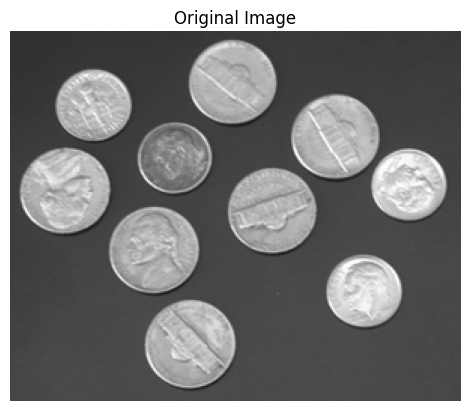

In [40]:
img = cv2.imread('Coin.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print('Image shape:', img.shape)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')
plt.show()

## 2. Sửa dụng hàm có sẵn để chuyển đổi từ không gian màu RGB sang XYZ, CMYK, Lab và HSV.

XYZ shape: (246, 300, 3)
Lab shape: (246, 300, 3)
HSV shape: (246, 300, 3)
CMYK shape: (246, 300, 4)


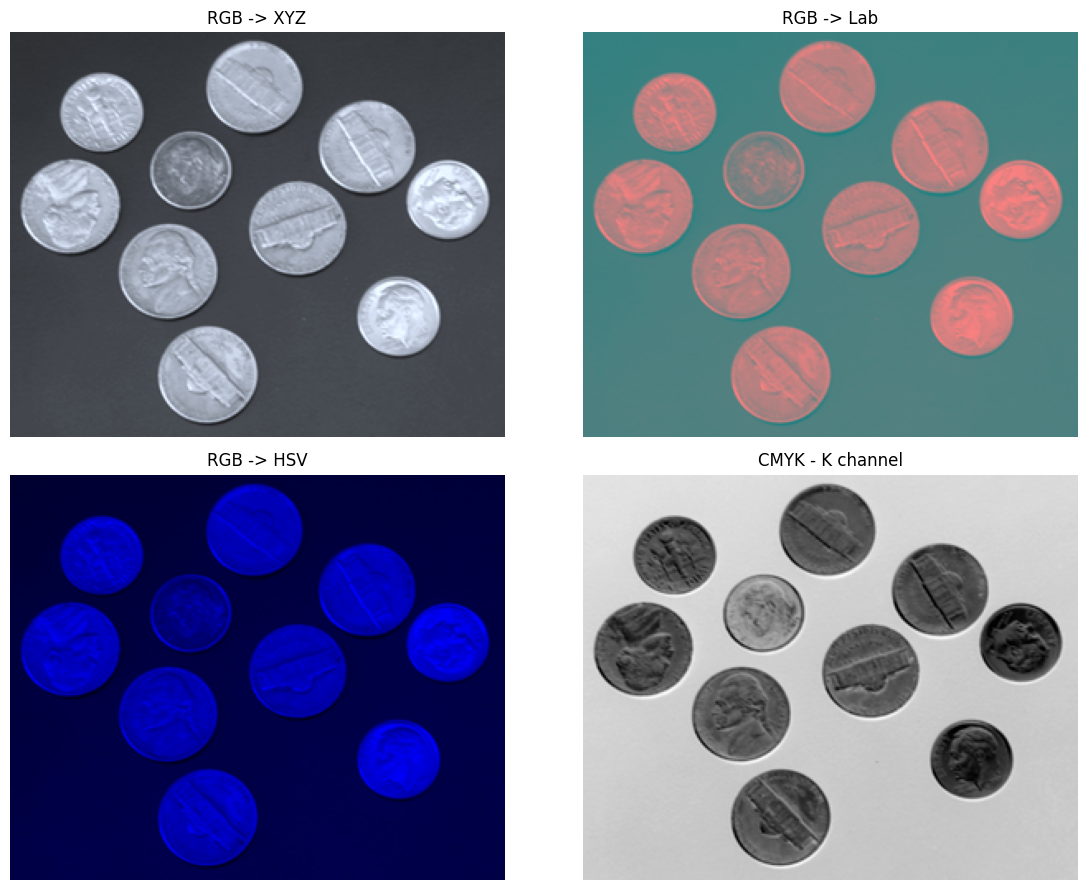

In [41]:
# RGB -> XYZ, Lab, HSV (OpenCV expects RGB input for these conversion codes)
img_xyz = cv2.cvtColor(img, cv2.COLOR_RGB2XYZ)
img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

# RGB -> CMYK (manual conversion)
rgb_norm = img.astype(np.float32) / 255.0
k = 1 - np.max(rgb_norm, axis=2)
den = np.maximum(1 - k, 1e-8)
c = (1 - rgb_norm[:, :, 0] - k) / den
m = (1 - rgb_norm[:, :, 1] - k) / den
y = (1 - rgb_norm[:, :, 2] - k) / den
img_cmyk = np.dstack([c, m, y, k])

print('XYZ shape:', img_xyz.shape)
print('Lab shape:', img_lab.shape)
print('HSV shape:', img_hsv.shape)
print('CMYK shape:', img_cmyk.shape)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

axes[0].imshow(img_xyz)
axes[0].set_title('RGB -> XYZ')
axes[0].axis('off')

axes[1].imshow(img_lab)
axes[1].set_title('RGB -> Lab')
axes[1].axis('off')

axes[2].imshow(img_hsv)
axes[2].set_title('RGB -> HSV')
axes[2].axis('off')

axes[3].imshow(img_cmyk[:, :, 3], cmap='gray')
axes[3].set_title('CMYK - K channel')
axes[3].axis('off')

plt.tight_layout()
plt.show()

## 3. Chuyển đổi ảnh coin sang ảnh gray (có thể dùng hàm chuyến đổi hoặc tách một trong 3 kênh màu của mô hình màu RGB).

Gray shape: (246, 300)


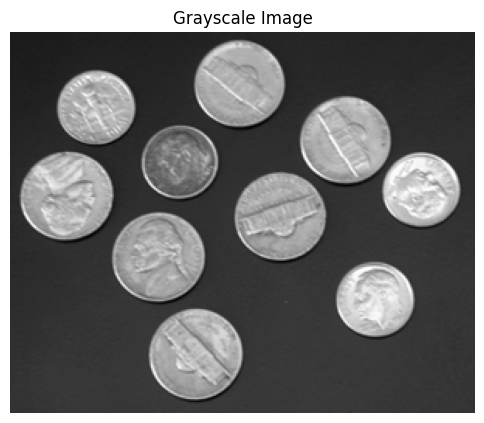

In [42]:
# Convert RGB to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

print('Gray shape:', gray.shape)
plt.figure(figsize=(6, 6))
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

## 4. Sử dụng global threshold là 100 để phân tách các đồng xu.

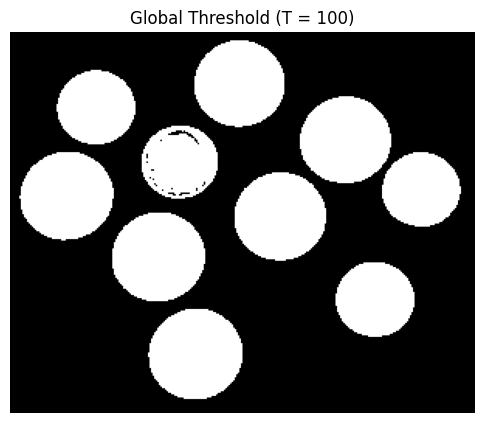

In [43]:
# Global threshold = 100
_, global_thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(6, 6))
plt.imshow(global_thresh, cmap='gray')
plt.title('Global Threshold (T = 100)')
plt.axis('off')
plt.show()

## 5. Sử dụng Otsu thresholding để xác định ngưỡng toàn cục và phân tách các đồng xu.

Otsu threshold value: 126.0


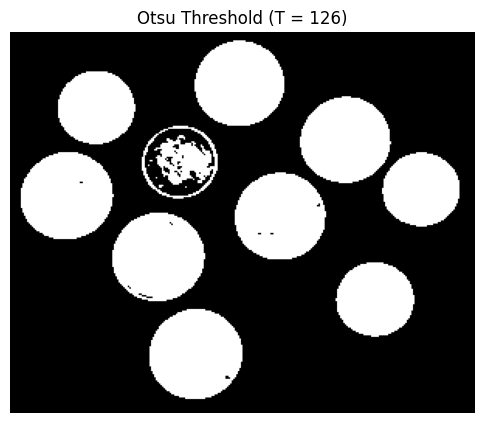

In [44]:
# Otsu thresholding (automatic global threshold)
otsu_T, otsu_thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print('Otsu threshold value:', otsu_T)
plt.figure(figsize=(6, 6))
plt.imshow(otsu_thresh, cmap='gray')
plt.title(f'Otsu Threshold (T = {otsu_T:.0f})')
plt.axis('off')
plt.show()

## 6. Sử dụng adaptive thresholding để tách các đồng xu.

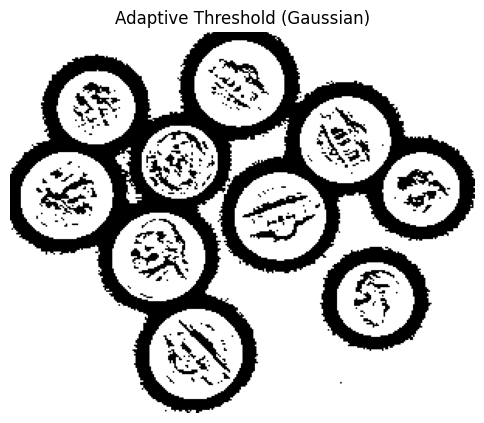

In [45]:
# Adaptive thresholding (Gaussian)
adaptive_thresh = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    35,
    5
)

plt.figure(figsize=(6, 6))
plt.imshow(adaptive_thresh, cmap='gray')
plt.title('Adaptive Threshold (Gaussian)')
plt.axis('off')
plt.show()

## 7. Dựa vào kết quà phân đoạn tốt nhất (trong các câu 4-6) để gán nhãn các vùng ảnh.

In [54]:
def prepare_binary_for_labeling(binary_img):
    # Ensure coins are white objects on black background
    bin_img = binary_img.copy()
    white_ratio = np.mean(bin_img == 255)
    if white_ratio > 0.5:
        bin_img = cv2.bitwise_not(bin_img)

    # Remove small noise
    kernel = np.ones((3, 3), np.uint8)
    bin_img = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, kernel, iterations=1)
    return bin_img


def count_valid_regions(binary_img, min_area=200):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_img, connectivity=8)
    areas = stats[1:, cv2.CC_STAT_AREA]
    valid = areas[areas >= min_area]
    return len(valid), (num_labels, labels, stats)


def build_label_visualization(binary_img):
    count, (num_labels, labels, stats) = count_valid_regions(binary_img, min_area=200)
    label_viz = np.zeros((labels.shape[0], labels.shape[1], 3), dtype=np.uint8)
    rng = np.random.default_rng(42)
    for label_id in range(1, num_labels):
        area = stats[label_id, cv2.CC_STAT_AREA]
        if area >= 200:
            color = rng.integers(0, 255, size=3, dtype=np.uint8)
            label_viz[labels == label_id] = color
    return count, label_viz


def plot_result_rows(original_img, results):
    if not results:
        return

    fig, axes = plt.subplots(len(results), 3, figsize=(21, 5 * len(results)))
    if len(results) == 1:
        axes = np.array([axes])

    for row_idx, (method_name, binary_img, label_viz) in enumerate(results):
        axes[row_idx, 0].imshow(original_img)
        axes[row_idx, 0].set_title('Original Image')
        axes[row_idx, 0].axis('off')

        axes[row_idx, 1].imshow(binary_img, cmap='gray')
        axes[row_idx, 1].set_title(f'{method_name} Mask')
        axes[row_idx, 1].axis('off')

        axes[row_idx, 2].imshow(label_viz)
        axes[row_idx, 2].set_title(f'{method_name} Labeled Regions')
        axes[row_idx, 2].axis('off')

    plt.tight_layout()
    plt.show()

Đánh giá dựa trên con người

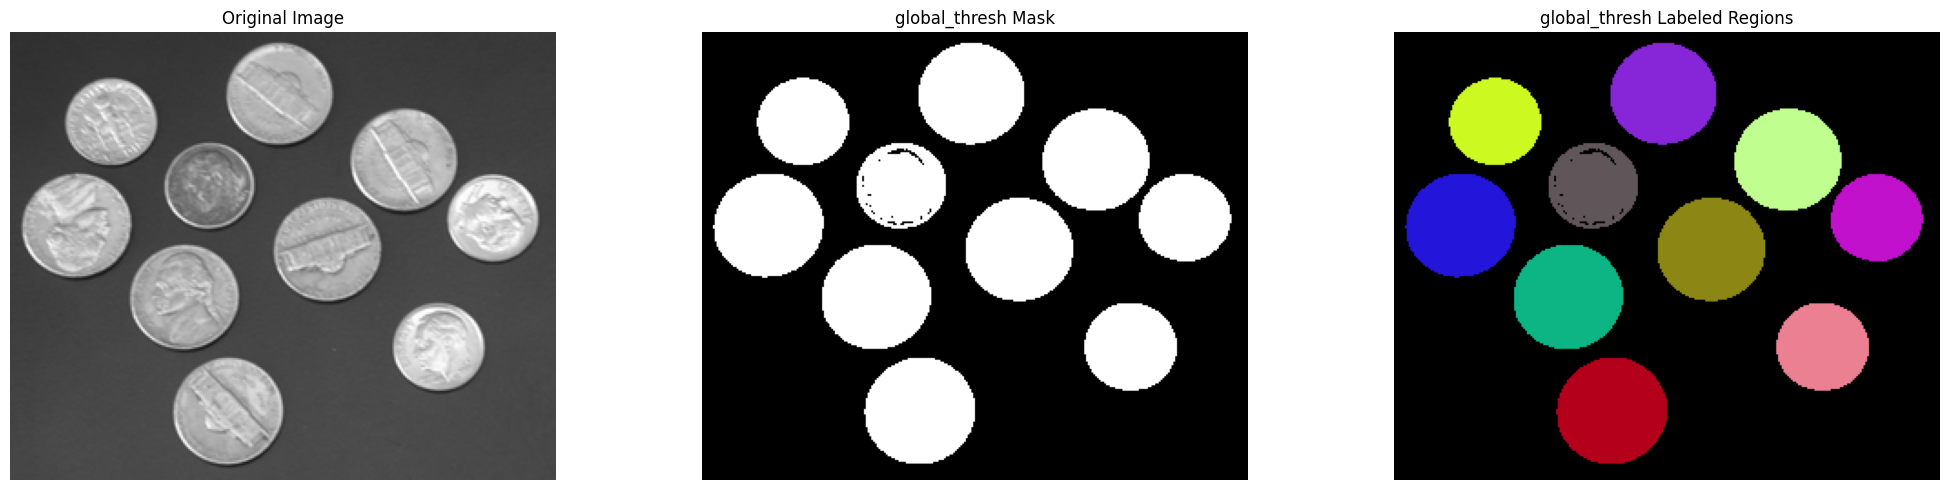

In [55]:
## Chất lượng binary của Gobal thresholding T=100 là tốt nhất

_, label_viz = build_label_visualization(global_thresh)
plot_result_rows(img, [('global_thresh',global_thresh, label_viz)])

Đánh giá bằng code

Expected coin count: 10
Region counts by method: {'Global T=100': 10, 'Otsu': 10, 'Adaptive Gaussian': 2}
Selected method(s): ['Global T=100', 'Otsu']


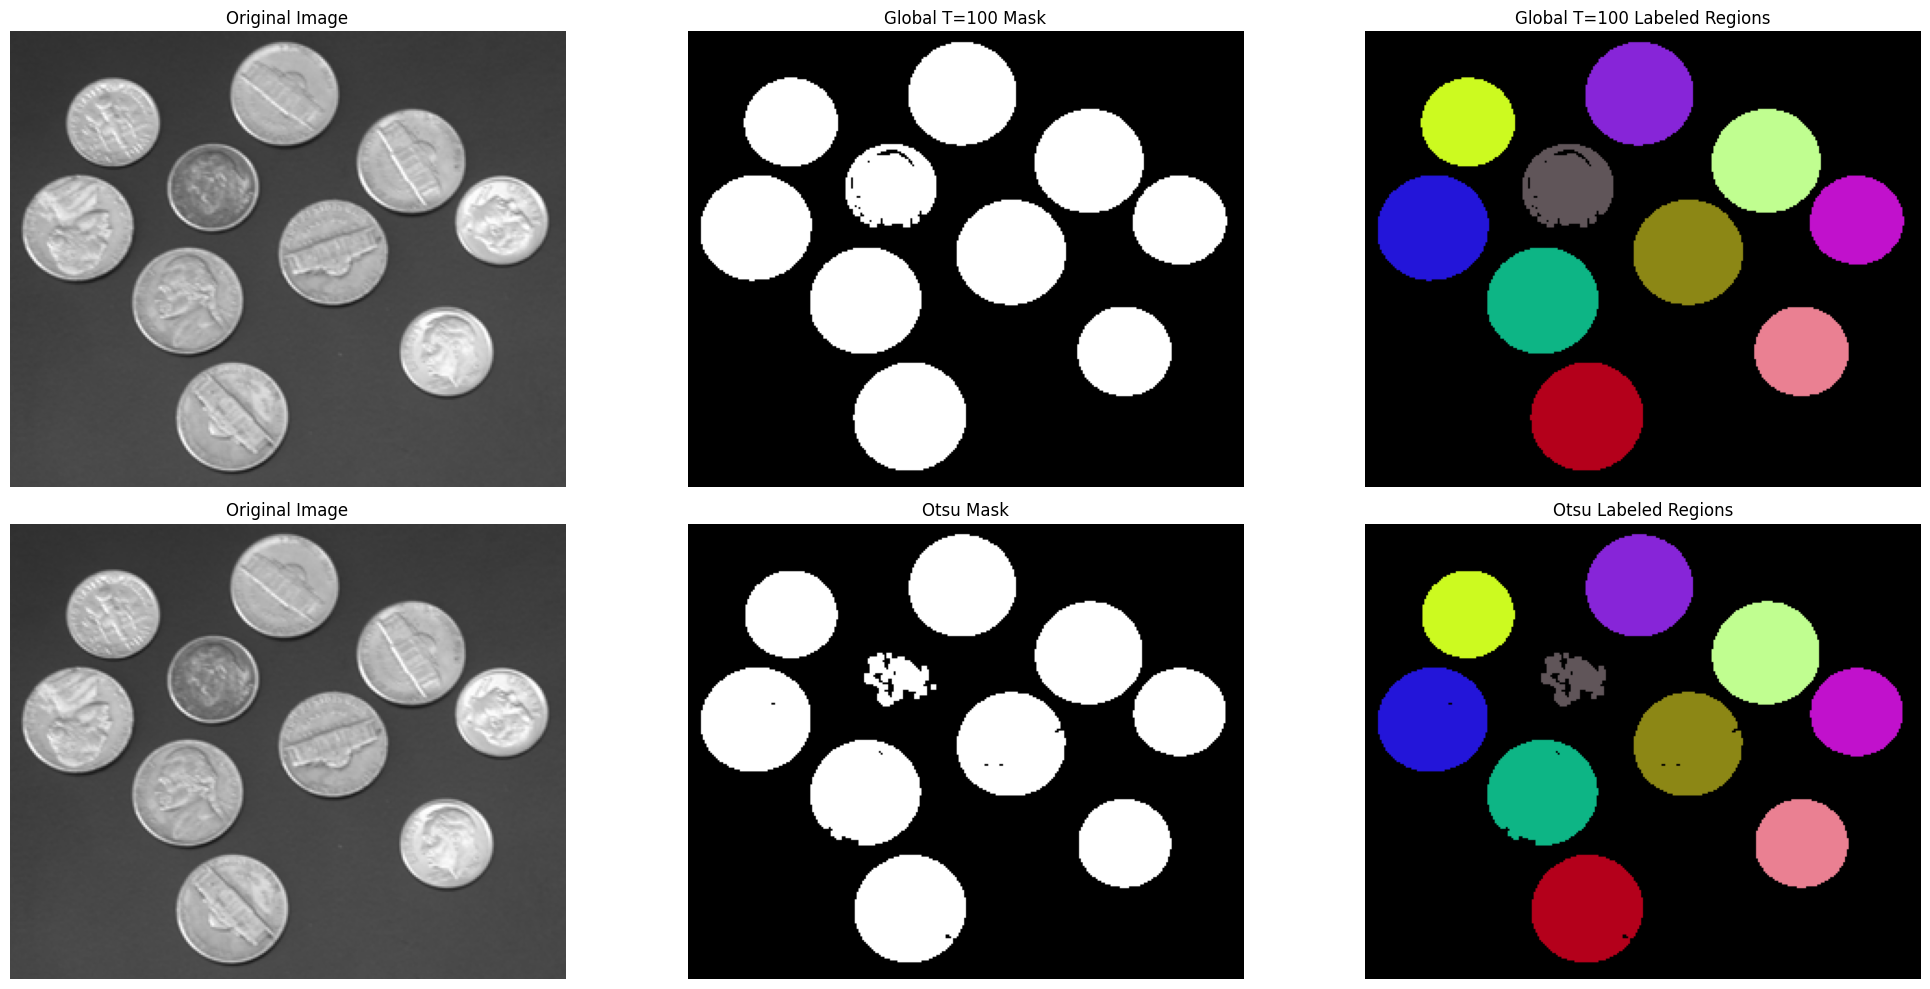

In [58]:
expected_coin_count = 10  # Số lượng đồng xu thực tế 

candidates = {
    'Global T=100': global_thresh,
    'Otsu': otsu_thresh,
    'Adaptive Gaussian': adaptive_thresh,
}

prepared = {name: prepare_binary_for_labeling(mask) for name, mask in candidates.items()} # Chuẩn hóa binary để đếm vùng chính xác hơn, xóa các vùng nhỏ,...
# prepared = {name: mask for name, mask in candidates.items()} # Dùng ảnh trực tiếp

scores = {}
cache = {}

for name, mask in prepared.items():
    count, cc_data = count_valid_regions(mask, min_area=200)
    scores[name] = count
    cache[name] = (mask, cc_data)

exact_matches = [name for name, count in scores.items() if count == expected_coin_count]

if exact_matches:
    selected_methods = exact_matches
else:
    min_diff = min(abs(count - expected_coin_count) for count in scores.values())
    selected_methods = [name for name, count in scores.items() if abs(count - expected_coin_count) == min_diff]

best_methods = selected_methods
best_method = best_methods[0]
best_binary, (num_labels, labels, stats) = cache[best_method]

print('Expected coin count:', expected_coin_count)
print('Region counts by method:', scores)
print('Selected method(s):', best_methods)

# Build color label maps for the selected method(s)
selected_results = []
for method_name in best_methods:
    binary_img, _ = cache[method_name]
    _, label_viz = build_label_visualization(binary_img)
    selected_results.append((method_name, binary_img, label_viz))


plot_result_rows(img, selected_results)

## 8. Đếm số lượng đồng xu trong ảnh dựa trên các vùng đã được gán nhãn.

Số lượng đồng xu thực tế: 10 coins
Best method: Global T=100
Số lượng đồng xu đếm được: 10 coins


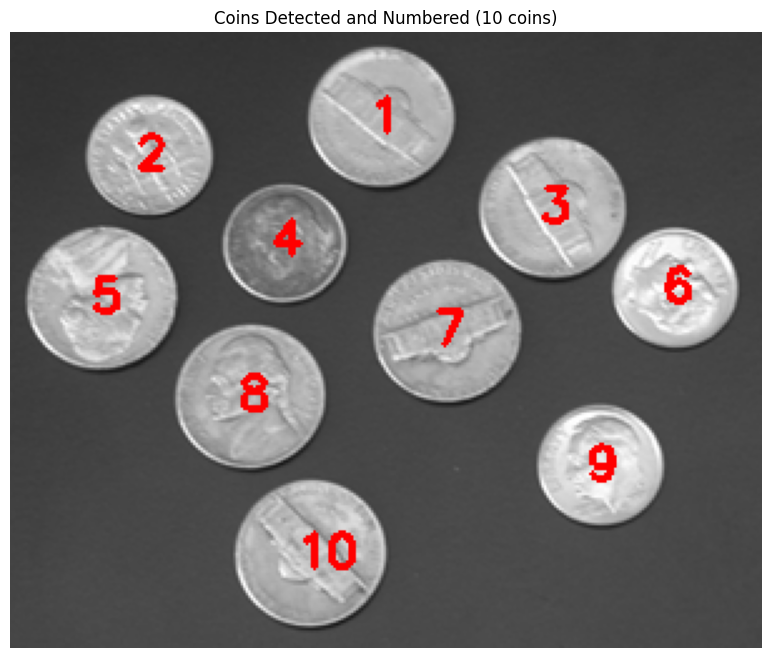

In [65]:
# Count coins using the best binary mask
coin_count, (num_labels, labels, stats) = count_valid_regions(best_binary, min_area=200)

print('Số lượng đồng xu thực tế:', expected_coin_count, 'coins')
print('Best method:', best_method)
print('Số lượng đồng xu đếm được:', coin_count, 'coins')

# Draw coin positions with numbers on the original image
img_with_numbers = img.copy()
coin_idx = 1
for label_id in range(1, num_labels):
    area = stats[label_id, cv2.CC_STAT_AREA]
    if area >= 200:
        # Get centroid
        cx = int(stats[label_id, cv2.CC_STAT_LEFT] + stats[label_id, cv2.CC_STAT_WIDTH] / 2)
        cy = int(stats[label_id, cv2.CC_STAT_TOP] + stats[label_id, cv2.CC_STAT_HEIGHT] / 2)
        
        # Draw
        # cv2.circle(img_with_numbers, (cx, cy), 15, (0, 255, 0), 2)
        cv2.putText(img_with_numbers, str(coin_idx), (cx - 5, cy + 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
        coin_idx += 1

# Display the image with coin numbers
plt.figure(figsize=(10, 8))
plt.imshow(img_with_numbers)
plt.title(f'Coins Detected and Numbered ({coin_count} coins)')
plt.axis('off')
plt.show()

